In [1]:
# Libraries ----
import sys
import warnings
import pandas as pd  # type: ignore

sys.path.append("../modules")
import plot_hoi as ph  # type: ignore
import plot_complexity as pc  # type: ignore
import plot_synchronization as ps  # type: ignore
import plot_complex_network_analysis as pcna  # type: ignore

# Global options ----
warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None
pd.set_option("display.max_columns", None)

## Global variables

In [2]:
log_path = "../logs"
input_path = "../input_files"
output_path = "../output_files"
input_generation_date = "20250801"
x_bounds = [0, 1920]
y_bounds = [0, 1080]
t_threshold = 3600

### Load processed data for time series and elementary symmetric polynomials

In [3]:
# High-Order interactions (HoI)
df_oinfo_1 = pd.read_csv(output_path + "/df_hoi.csv", low_memory=False, dtype={"multiplet": str})
df_oinfo_2 = pd.read_csv(output_path + "/df_hoi_esp.csv", low_memory=False, dtype={"multiplet": str})
df_oinfo_3 = pd.read_csv(output_path + "/df_hoi_sim.csv", low_memory=False, dtype={"multiplet": str})
df_oinfo_4 = pd.read_csv(output_path + "/df_hoi_sim_esp.csv", low_memory=False, dtype={"multiplet": str})

# Complexity measures
df_complexity_1 = pd.read_csv(output_path + "/df_complexity.csv", low_memory=False)
df_complexity_2 = pd.read_csv(output_path + "/df_complexity_esp.csv", low_memory=False)
df_complexity_3 = pd.read_csv(output_path + "/df_complexity_sim.csv", low_memory=False)
df_complexity_4 = pd.read_csv(output_path + "/df_complexity_sim_esp.csv", low_memory=False)

# Recurrence plots (Synchronization)
df_metrics_1 = pd.read_csv(output_path + "/df_recurrence.csv", low_memory=False, dtype={"id_pair": str})
df_metrics_2 = pd.read_csv(output_path + "/df_recurrence_esp.csv", low_memory=False, dtype={"id_pair": str})
df_metrics_3 = pd.read_csv(output_path + "/df_recurrence_sim.csv", low_memory=False, dtype={"id_pair": str})
df_metrics_4 = pd.read_csv(output_path + "/df_recurrence_sim_esp.csv", low_memory=False, dtype={"id_pair": str})

df_metrics_1 = df_metrics_1[df_metrics_1["id_pair"].isin(["00", "11", "22", "33"])]
df_metrics_2 = df_metrics_2[df_metrics_2["id_pair"].isin(["00", "11", "22", "33"])]
df_metrics_3 = df_metrics_3[df_metrics_3["id_pair"].isin(["00", "11", "22", "33"])]
df_metrics_4 = df_metrics_4[df_metrics_4["id_pair"].isin(["00", "11", "22", "33"])]

# Kuramoto model
df_synchronization_1 = pd.read_csv(output_path + "/df_kuramoto.csv", low_memory=False)
df_synchronization_2 = pd.read_csv(output_path + "/df_kuramoto_esp.csv", low_memory=False)
df_synchronization_3 = pd.read_csv(output_path + "/df_kuramoto_sim.csv", low_memory=False)
df_synchronization_4 = pd.read_csv(output_path + "/df_kuramoto_sim_esp.csv", low_memory=False)

# Network analysis
df_network_1 = pd.read_csv(output_path + "/df_network.csv", low_memory=False)
df_network_2 = pd.read_csv(output_path + "/df_network_esp.csv", low_memory=False)
df_network_3 = pd.read_csv(output_path + "/df_network_sim.csv", low_memory=False)
df_network_4 = pd.read_csv(output_path + "/df_network_sim_esp.csv", low_memory=False)

df_nodes_1 = pd.read_csv(output_path + "/df_network_nodes.csv", low_memory=False)
df_nodes_2 = pd.read_csv(output_path + "/df_network_nodes_esp.csv", low_memory=False)
df_nodes_3 = pd.read_csv(output_path + "/df_network_nodes_sim.csv", low_memory=False)
df_nodes_4 = pd.read_csv(output_path + "/df_network_nodes_sim_esp.csv", low_memory=False)

## Plot time series of each individual

# Are there higher-order interactions in 3 and 4 cockroach videos?

- Aim: To classify regimes as redundancy-dominated or synergy-dominated over time.
- Data: Distances from the center of the box and orientation of the cockroaches respect to the vertical.

## Get O-information data between individuals
O-Information is a measure used in information theory to quantify **high-order interactions** in multivariate systems. It distinguishes between redundant and synergistic information sharing across multiple variables.

### **Mathematical Formulation**

For a set of random variables $(X_1, X_2, ..., X_N)$, the O-Information and exogenous information are defined as:

\begin{align}
    \Omega(X_1, X_2, ..., X_N) &= TC(\mathbf{X}_{n}) - DTC(\mathbf{X}_{n}) = \sum_{i=1}^{N} I(X_i; \mathbf{X}_{-i}) - I(\mathbf{X}_1, ..., \mathbf{X}_N) \\
    S(X_1, X_2, ..., X_N) &= TC(\mathbf{X}_{n}) + DTC(\mathbf{X}_{n})
\end{align}

respectively, where:

- $I(X_i; \mathbf{X}_{-i})$ is the mutual information between $X_i$ and the rest.
- $I(\mathbf{X}_1, ..., \mathbf{X}_N)$ is the total multivariate mutual information.
- If $\Omega>0$, the system is redundancy-dominated.
- If $\Omega<0$, the system is synergy-dominated.


In [4]:
for video in df_oinfo_1["video"].unique():
    fig_oinfo, ax_oinfo = ph.plot_gliding_oinfo(
        df_oinfo=df_oinfo_1[df_oinfo_1["video"] == video],
        width=16,
        height=5,
        n_x_breaks=20,
        n_y_breaks=20,
        fancy_legend=True,
        save_figure=True,
        output_path=output_path + "/" + input_generation_date,
        output_name="plot_gliding_oinfo_" + video
    )

for video in df_oinfo_2["video"].unique():
    fig_oinfo, ax_oinfo = ph.plot_gliding_oinfo(
        df_oinfo=df_oinfo_2[df_oinfo_2["video"] == video],
        width=16,
        height=5,
        n_x_breaks=20,
        n_y_breaks=20,
        fancy_legend=True,
        save_figure=True,
        output_path=output_path + "/" + input_generation_date,
        output_name="plot_gliding_oinfo_esp_" + video
    )

for video in df_oinfo_3["video"].unique():
    fig_oinfo, ax_oinfo = ph.plot_gliding_oinfo(
        df_oinfo=df_oinfo_3[df_oinfo_3["video"] == video],
        width=16,
        height=5,
        n_x_breaks=20,
        n_y_breaks=20,
        fancy_legend=True,
        save_figure=True,
        output_path=output_path + "/" + input_generation_date,
        output_name="plot_gliding_oinfo_sim_" + video
    )

for video in df_oinfo_4["video"].unique():
    fig_oinfo, ax_oinfo = ph.plot_gliding_oinfo(
        df_oinfo=df_oinfo_4[df_oinfo_4["video"] == video],
        width=16,
        height=5,
        n_x_breaks=20,
        n_y_breaks=20,
        fancy_legend=True,
        save_figure=True,
        output_path=output_path + "/" + input_generation_date,
        output_name="plot_gliding_oinfo_sim_esp_" + video
    )

Figure saved to ../output_files/20250801\plot_gliding_oinfo_3n_0m_3f_230404_1.png
Figure saved to ../output_files/20250801\plot_gliding_oinfo_3n_0m_3f_230404_2.png
Figure saved to ../output_files/20250801\plot_gliding_oinfo_3n_0m_3f_240215_1.png
Figure saved to ../output_files/20250801\plot_gliding_oinfo_3n_1m_2f_240213_1.png
Figure saved to ../output_files/20250801\plot_gliding_oinfo_3n_1m_2f_240215_1.png
Figure saved to ../output_files/20250801\plot_gliding_oinfo_3n_1m_2f_240216_1.png
Figure saved to ../output_files/20250801\plot_gliding_oinfo_3n_1m_2f_240216_2.png
Figure saved to ../output_files/20250801\plot_gliding_oinfo_4n_4m_0f_230523_2.png
Figure saved to ../output_files/20250801\plot_gliding_oinfo_esp_3n_0m_3f_230404_1.png
Figure saved to ../output_files/20250801\plot_gliding_oinfo_esp_3n_0m_3f_230404_2.png
Figure saved to ../output_files/20250801\plot_gliding_oinfo_esp_3n_0m_3f_240215_1.png
Figure saved to ../output_files/20250801\plot_gliding_oinfo_esp_3n_1m_2f_240213_1.png


In [5]:
k1_11, k1_12, fig_oinfo_11, fig_oinfo_12, ax_oinfo_11, ax_oinfo_12 = ph.plot_hoi_metrics_summary(
    df_oinfo=df_oinfo_1,
    width=16,
    height=8,
    n_x_breaks=20,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_oinfo_summary"
)

k1_21, k1_22, fig_oinfo_21, fig_oinfo_22, ax_oinfo_21, ax_oinfo_22 = ph.plot_hoi_metrics_summary(
    df_oinfo=df_oinfo_2,
    width=16,
    height=8,
    n_x_breaks=20,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_oinfo_esp_summary"
)

k1_31, k1_32, fig_oinfo_31, fig_oinfo_32, ax_oinfo_31, ax_oinfo_32 = ph.plot_hoi_metrics_summary(
    df_oinfo=df_oinfo_3,
    width=16,
    height=8,
    n_x_breaks=20,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_oinfo_sim_summary"
)

k1_41, k1_42, fig_oinfo_41, fig_oinfo_42, ax_oinfo_41, ax_oinfo_42 = ph.plot_hoi_metrics_summary(
    df_oinfo=df_oinfo_4,
    width=16,
    height=8,
    n_x_breaks=20,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_oinfo_sim_esp_summary"
)

Figure saved to ../output_files\plot_gliding_oinfo_summary_video.png and ../output_files\plot_gliding_oinfo_summary_sexratio.png
Figure saved to ../output_files\plot_gliding_oinfo_esp_summary_video.png and ../output_files\plot_gliding_oinfo_esp_summary_sexratio.png
Figure saved to ../output_files\plot_gliding_oinfo_sim_summary_video.png and ../output_files\plot_gliding_oinfo_sim_summary_sexratio.png
Figure saved to ../output_files\plot_gliding_oinfo_sim_esp_summary_video.png and ../output_files\plot_gliding_oinfo_sim_esp_summary_sexratio.png


---
# How different is the behavior when sex ratio changes (fixed group size)?

- Aim: To estimate Hurst exponent (asses persistence), Permutation entropy (predictability), Statistical complexity (assess the balance of order and randomness) for each cockroach’s time series (distance, orientation) → persistence vs. randomness.
- Data: Distances from the center of the box and orientation of the cockroaches respect to the vertical.
---

## Get Hurst exponent, permutation entropy and Statistical complexity data between individuals

### **Mathematical Formulation**

#### 1. Hurst Exponent

The Hurst exponent ($H$) is a statistical measure used to evaluate the long-term memory of time series data. It quantifies the tendency of a time series to either:

- Persist in its trend ($H > 0.5$)
- Exhibit a random walk ($H ≈ 0.5$)
- Mean-revert (antipersistence) ($H < 0.5$)

The Hurst exponent is estimated using the rescaled range (R/S) analysis:

\begin{equation}
    H = \lim_{T \to \infty} \frac{\log(R/S)}{\log(T)},
\end{equation}

where $R$ is the range of cumulative deviations from the mean, $S$ is the standard deviation, and $T$ is the time window size.

Also, Multifractal Detrended Fluctuation Analysis (MF-DFA) is an extension of DFA (Detrended Fluctuation Analysis) that measures the **multifractal properties** of a time series by analyzing its scaling behavior at different moments $q$. The fluctuation function is defined as:

\begin{equation}
    F_q(s) = \left( \frac{1}{N_s} \sum_{\nu=1}^{N_s} F^q(\nu, s) \right)^{\frac{1}{q}}
\end{equation}

where $F(\nu, s)$ is the local detrended fluctuation at segment $\nu$, and $s$ is the window size.

#### 2. Permutation Entropy

Permutation Entropy ($PE$) is a nonlinear measure of time series complexity introduced by Bandt & Pompe (2002). It quantifies the randomness in a time series by analyzing the frequency of ordinal patterns of a given length.

Given a time series $X = \{x_1, x_2, ..., x_N\}$ and an embedding dimension $d$, we extract ordinal patterns by ranking the values within sliding windows of size $\tau$. The permutation entropy is then computed as:

\begin{equation}
    H_p = - \sum p(\pi) \log p(\pi)
\end{equation}

where $p(\pi)$ is the probability of each ordinal pattern $\pi$.

#### 3. Statistical complexity

Statistical complexity measures the balance between disorder and structure in a system. It complements entropy by identifying structured patterns within randomness.

A widely used definition is the **Jensen-Shannon complexity**, which combines permutation entropy and disequilibrium:

\begin{equation}
    C_J = H_p \cdot Q_J
\end{equation}

where $Q_J$ is the Jensen-Shannon divergence measuring disequilibrium.

---
## **References**

- Bandt, C., & Pompe, B. (2002). Permutation entropy: A natural complexity measure for time series.
- Rosso, O. A., et al. (2007). Distinguishing noise from chaos.
- Ribeiro, H. V., et al. (2012). Characterizing time series through complexity-entropy curves.
- `ordpy`: A Python library for ordinal pattern analysis.
---

In [6]:
for video in df_complexity_1["video"].unique():
    fig_complexity, ax_complexity = pc.plot_gliding_complexity(
        df_complexity=df_complexity_1[df_complexity_1["video"] == video],
        width=16,
        height=8,
        n_x_breaks=20,
        n_y_breaks=20,
        fancy_legend=True,
        save_figure=True,
        output_path=output_path + "/" + input_generation_date,
        output_name="plot_gliding_complexity_" + video
    )

for video in df_complexity_2["video"].unique():
    fig_complexity, ax_complexity = pc.plot_gliding_complexity(
        df_complexity=df_complexity_2[df_complexity_2["video"] == video],
        width=16,
        height=8,
        n_x_breaks=20,
        n_y_breaks=20,
        fancy_legend=True,
        save_figure=True,
        output_path=output_path + "/" + input_generation_date,
        output_name="plot_gliding_complexity_esp_" + video
    )

for video in df_complexity_3["video"].unique():
    fig_complexity, ax_complexity = pc.plot_gliding_complexity(
        df_complexity=df_complexity_3[df_complexity_3["video"] == video],
        width=16,
        height=8,
        n_x_breaks=20,
        n_y_breaks=20,
        fancy_legend=True,
        save_figure=True,
        output_path=output_path + "/" + input_generation_date,
        output_name="plot_gliding_complexity_sim_" + video
    )

for video in df_complexity_4["video"].unique():
    fig_complexity, ax_complexity = pc.plot_gliding_complexity(
        df_complexity=df_complexity_4[df_complexity_4["video"] == video],
        width=16,
        height=8,
        n_x_breaks=20,
        n_y_breaks=20,
        fancy_legend=True,
        save_figure=True,
        output_path=output_path + "/" + input_generation_date,
        output_name="plot_gliding_complexity_sim_esp_" + video
    )

Figure saved to ../output_files/20250801\plot_gliding_complexity_2n_0m_2f_230330_1.png
Figure saved to ../output_files/20250801\plot_gliding_complexity_2n_0m_2f_230404_1.png
Figure saved to ../output_files/20250801\plot_gliding_complexity_2n_0m_2f_230522_2.png
Figure saved to ../output_files/20250801\plot_gliding_complexity_2n_0m_2f_230522_3.png
Figure saved to ../output_files/20250801\plot_gliding_complexity_2n_0m_2f_230523_1.png
Figure saved to ../output_files/20250801\plot_gliding_complexity_2n_1m_1f_230522_1.png
Figure saved to ../output_files/20250801\plot_gliding_complexity_2n_1m_1f_240215_1.png
Figure saved to ../output_files/20250801\plot_gliding_complexity_2n_1m_1f_240219_1.png
Figure saved to ../output_files/20250801\plot_gliding_complexity_2n_1m_1f_240219_2.png
Figure saved to ../output_files/20250801\plot_gliding_complexity_2n_1m_1f_240226_1.png
Figure saved to ../output_files/20250801\plot_gliding_complexity_3n_0m_3f_230404_1.png
Figure saved to ../output_files/20250801\pl

In [7]:
k1_complexity_11, k1_complexity_12, fig_complexity_11, fig_complexity_12, ax_complexity_11, ax_complexity_12 = pc.plot_complexity_metrics_summary(
    df_complexity=df_complexity_1,
    width=18,
    height=12,
    n_x_breaks=20,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_complexity_summary"
)

k1_complexity_21, k1_complexity_22, fig_complexity_21, fig_complexity_22, ax_complexity_21, ax_complexity_22 = pc.plot_complexity_metrics_summary(
    df_complexity=df_complexity_2,
    width=18,
    height=12,
    n_x_breaks=20,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_complexity_esp_summary"
)

k1_complexity_31, k1_complexity_32, fig_complexity_31, fig_complexity_32, ax_complexity_31, ax_complexity_32 = pc.plot_complexity_metrics_summary(
    df_complexity=df_complexity_3,
    width=18,
    height=12,
    n_x_breaks=20,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_complexity_sim_summary"
)

k1_complexity_41, k1_complexity_42, fig_complexity_41, fig_complexity_42, ax_complexity_41, ax_complexity_42 = pc.plot_complexity_metrics_summary(
    df_complexity=df_complexity_4,
    width=18,
    height=12,
    n_x_breaks=20,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_complexity_sim_esp_summary"
)

Figure saved to ../output_files\plot_gliding_complexity_summary_video.png and ../output_files\plot_gliding_complexity_summary_sexratio.png
Figure saved to ../output_files\plot_gliding_complexity_esp_summary_video.png and ../output_files\plot_gliding_complexity_esp_summary_sexratio.png
Figure saved to ../output_files\plot_gliding_complexity_sim_summary_video.png and ../output_files\plot_gliding_complexity_sim_summary_sexratio.png
Figure saved to ../output_files\plot_gliding_complexity_sim_esp_summary_video.png and ../output_files\plot_gliding_complexity_sim_esp_summary_sexratio.png


---
# How different is the behavior when sex ratio changes (fixed group size)?

- Aim: To examine coordination and coupling using Cross-recurrence quantification analysis (CRQA).
- Data: Distances from the center of the box and orientation of the cockroaches respect to the vertical.
---

## Synchronization in Complex Systems

### **Mathematical Formulation**

#### 1. Recurrence Plot Analysis (RPA)

**Recurrence Plot Analysis (RPA)** is a nonlinear method for studying the dynamics and synchronization of complex systems. It visualizes when a system revisits the same or similar state in its phase space.

Given a trajectory $\vec{x}_i \in \mathbb{R}^d$, the **recurrence matrix** is defined as:

\begin{equation}
    R_{i,j} = \Theta(\varepsilon - \|\vec{x}_i - \vec{x}_j\|),
\end{equation}

where:
- $\varepsilon$ is a threshold,
- $\Theta$ is the Heaviside step function,
- $R_{i,j} = 1$ means state $i$ recurs at time $j$.

The resulting binary matrix can be visualized as a **recurrence plot**.

**Recurrence Quantification Analysis (RQA)** converts the visual features of recurrence plots into quantitative metrics:

| Metric | Description |
|--------|-------------|
| **RR** – Recurrence Rate | Ratio of recurrent points in the plot |
| **DET** – Determinism | Fraction of recurrent points forming diagonal lines (indicating predictability) |
| **L** – Average Diagonal Line Length | Mean time over which the system exhibits similar behavior |
| **ENTR** – Entropy | Shannon entropy of diagonal line lengths (complexity measure) |
| **LAM** – Laminarity | Fraction of points forming vertical lines (indicating intermittency or stationarity) |
| **TT** – Trapping Time | Average vertical line length |

These metrics help detect patterns such as synchronization, chaos, and transitions in dynamics.

---

#### 2. Kuramoto Model & Synchronization

The **Kuramoto model** is a classical model for understanding synchronization in populations of coupled oscillators (e.g., neurons, fireflies, mechanical rotors).

Each oscillator $i$ has a phase $\theta_i(t)$, and their interaction is governed by:

\begin{equation}
    \frac{d\theta_i}{dt} = \omega_i + \frac{K}{N} \sum_{j=1}^{N} \sin(\theta_j - \theta_i),
\end{equation}

where:
- $\omega_i$ is the natural frequency,
- $K$ is the coupling strength,
- $N$ is the number of oscillators.

The **degree of synchronization** is measured by the **Kuramoto order parameter** $R(t)$:

\begin{equation}
    R(t) = \left| \frac{1}{N} \sum_{j=1}^{N} e^{i \theta_j(t)} \right|
\end{equation}

- $R(t) \in [0, 1]$
- $R(t) \approx 1$: perfect phase synchronization
- $R(t) \approx 0$: desynchronized or incoherent state

This metric summarizes global coherence in the system and is often visualized as a function of time or coupling strength $K$.

The **Kuramoto parameter** offers a global phase measure, while **RQA** captures finer nonlinear structures and local synchrony.

---

In [8]:
fig_recurrence_1, axes_recurrence_1 = ps.plot_crqa(
    df_metrics=df_metrics_1,
    width=14,
    height=10,
    n_y_breaks=10,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_recurrence_summary"
)

fig_recurrence_2, axes_recurrence_2 = ps.plot_crqa(
    df_metrics=df_metrics_2,
    width=14,
    height=10,
    n_y_breaks=10,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_recurrence_esp_summary"
)

fig_recurrence_3, axes_recurrence_3 = ps.plot_crqa(
    df_metrics=df_metrics_3,
    width=14,
    height=10,
    n_y_breaks=10,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_recurrence_sim_summary"
)

fig_recurrence_4, axes_recurrence_4 = ps.plot_crqa(
    df_metrics=df_metrics_4,
    width=14,
    height=10,
    n_y_breaks=10,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_recurrence_sim_esp_summary"
)

Figure saved to ../output_files\plot_gliding_recurrence_summary.png
Figure saved to ../output_files\plot_gliding_recurrence_esp_summary.png
Figure saved to ../output_files\plot_gliding_recurrence_sim_summary.png
Figure saved to ../output_files\plot_gliding_recurrence_sim_esp_summary.png


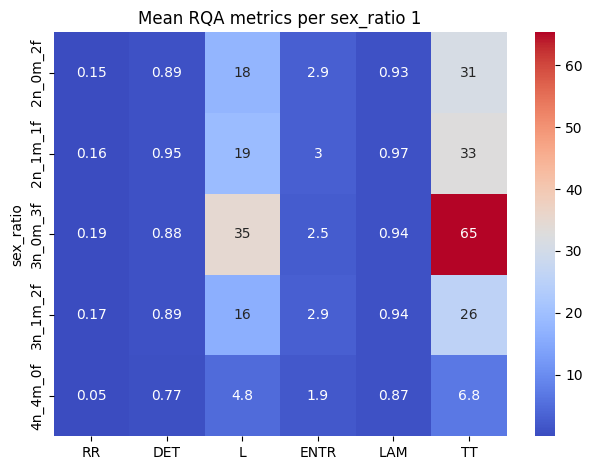

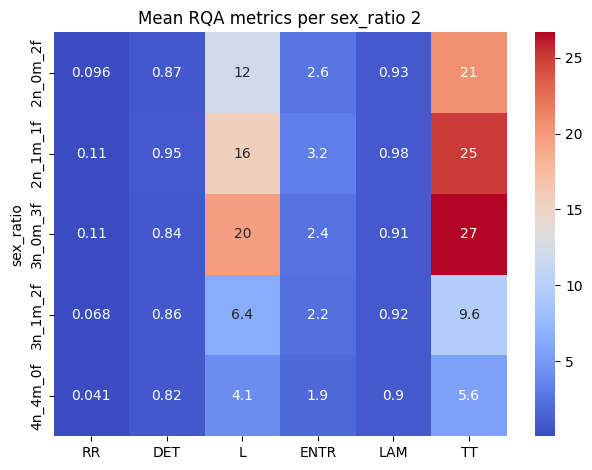

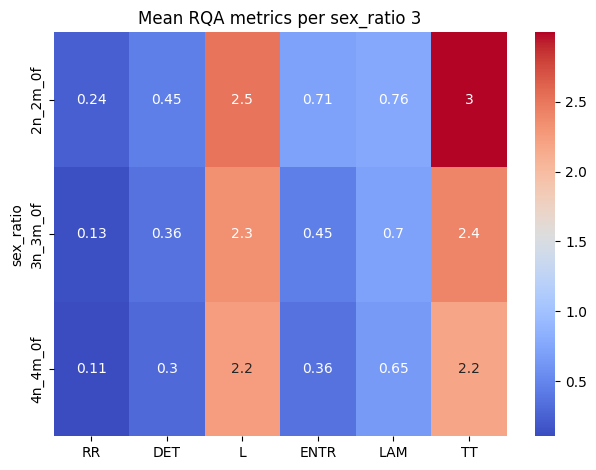

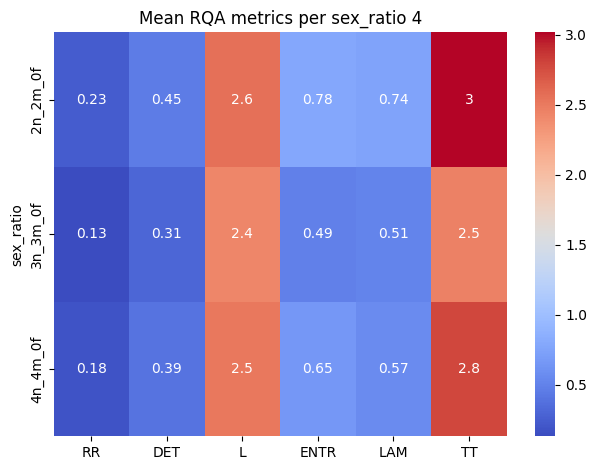

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

df_metrics_1["sex_ratio"] = df_metrics_1["video"].str[:8]
df_metrics_2["sex_ratio"] = df_metrics_2["video"].str[:8]
df_metrics_3["sex_ratio"] = df_metrics_3["video"].str[:8]
df_metrics_4["sex_ratio"] = df_metrics_4["video"].str[:8]

# Heat map with mean per variable
for i, df in enumerate([df_metrics_1, df_metrics_2, df_metrics_3, df_metrics_4], start=1):
    hd = df.groupby("sex_ratio")[["RR", "DET", "L", "ENTR", "LAM", "TT"]].mean()
    sns.heatmap(hd, annot=True, cmap="coolwarm")
    plt.title("Mean RQA metrics per sex_ratio " + str(i))
    plt.tight_layout()
    plt.show()


In [10]:
# Plot Kuramoto order parameter
fig_kuramoto_1, axes_kuramoto_1 = ps.plot_kuramoto_order_parameter(
    df_synchronization=df_synchronization_1,
    width=12,
    height=12,
    n_x_breaks=40,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_synchronization_summary"
)

fig_kuramoto_2, axes_kuramoto_2 = ps.plot_kuramoto_order_parameter(
    df_synchronization=df_synchronization_2,
    width=12,
    height=12,
    n_x_breaks=40,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_synchronization_esp_summary"
)

fig_kuramoto_3, axes_kuramoto_3 = ps.plot_kuramoto_order_parameter(
    df_synchronization=df_synchronization_3,
    width=12,
    height=12,
    n_x_breaks=40,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_synchronization_sim_summary"
)

fig_kuramoto_4, axes_kuramoto_4 = ps.plot_kuramoto_order_parameter(
    df_synchronization=df_synchronization_4,
    width=12,
    height=12,
    n_x_breaks=40,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_synchronization_sim_esp_summary"
)

Figure saved to ../output_files\plot_gliding_synchronization_summary.png
Figure saved to ../output_files\plot_gliding_synchronization_esp_summary.png
Figure saved to ../output_files\plot_gliding_synchronization_sim_summary.png
Figure saved to ../output_files\plot_gliding_synchronization_sim_esp_summary.png


In [11]:
# Plot Kuramoto order parameter
fig_kuramoto_1, axes_kuramoto_1 = ps.plot_kuramoto_order_parameter_2(
    df_synchronization=df_synchronization_1,
    width=6,
    height=6,
    n_y_breaks=20,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_synchronization_2_summary"
)

fig_kuramoto_2, axes_kuramoto_2 = ps.plot_kuramoto_order_parameter_2(
    df_synchronization=df_synchronization_2,
    width=6,
    height=6,
    n_y_breaks=20,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_synchronization_esp_2_summary"
)

fig_kuramoto_3, axes_kuramoto_3 = ps.plot_kuramoto_order_parameter_2(
    df_synchronization=df_synchronization_3,
    width=6,
    height=6,
    n_y_breaks=20,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_synchronization_sim_2_summary"
)

fig_kuramoto_4, axes_kuramoto_4 = ps.plot_kuramoto_order_parameter_2(
    df_synchronization=df_synchronization_4,
    width=6,
    height=6,
    n_y_breaks=20,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_synchronization_sim_esp_2_summary"
)

Figure saved to ../output_files\plot_gliding_synchronization_2_summary.png
Figure saved to ../output_files\plot_gliding_synchronization_esp_2_summary.png
Figure saved to ../output_files\plot_gliding_synchronization_sim_2_summary.png
Figure saved to ../output_files\plot_gliding_synchronization_sim_esp_2_summary.png


# How different is the behavior with different number of cockroaches?

- Aim: To quantify network properties (modularity, clustering, degree distribution).
- Data: Distances from the center of the box and orientation of the cockroaches respect to the vertical.

## Get Visibility Graph between individuals
The **Visibility Graph** ($VG$) is a method that transforms time series into a complex network, where data points in the series are mapped to nodes and edges are created based on visibility criteria.

### **Mathematical Formulation**
Given a time series $X = \{ x_1, x_2, ..., x_N \}$, two data points $(x_i, t_i)$ and $(x_j, t_j)$ are connected if any intermediate point $(x_k, t_k)$ satisfies:

\begin{equation}
    x_k < x_i + (x_j - x_i) \frac{t_k - t_i}{t_j - t_i}, \quad \forall k \in (i,j)
\end{equation}

In [12]:
for video in df_network_1["video"].unique():
    fig_complexity, ax_complexity = pcna.plot_gliding_complex_network(
        df_network_all=df_network_1[df_network_1["video"] == video],
        width=14,
        height=8,
        n_x_breaks=20,
        n_y_breaks=20,
        fancy_legend=True,
        save_figure=True,
        output_path=output_path + "/" + input_generation_date,
        output_name="plot_gliding_network_" + video
    )

for video in df_network_2["video"].unique():
    fig_complexity, ax_complexity = pcna.plot_gliding_complex_network(
        df_network_all=df_network_2[df_network_2["video"] == video],
        width=14,
        height=8,
        n_x_breaks=20,
        n_y_breaks=20,
        fancy_legend=True,
        save_figure=True,
        output_path=output_path + "/" + input_generation_date,
        output_name="plot_gliding_network_esp_" + video
    )

for video in df_network_3["video"].unique():
    fig_complexity, ax_complexity = pcna.plot_gliding_complex_network(
        df_network_all=df_network_3[df_network_3["video"] == video],
        width=14,
        height=8,
        n_x_breaks=20,
        n_y_breaks=20,
        fancy_legend=True,
        save_figure=True,
        output_path=output_path + "/" + input_generation_date,
        output_name="plot_gliding_network_sim_" + video
    )

for video in df_network_4["video"].unique():
    fig_complexity, ax_complexity = pcna.plot_gliding_complex_network(
        df_network_all=df_network_4[df_network_4["video"] == video],
        width=14,
        height=8,
        n_x_breaks=20,
        n_y_breaks=20,
        fancy_legend=True,
        save_figure=True,
        output_path=output_path + "/" + input_generation_date,
        output_name="plot_gliding_network_sim_esp_" + video
    )

Figure saved to ../output_files/20250801\plot_gliding_network_2n_0m_2f_230330_1.png
Figure saved to ../output_files/20250801\plot_gliding_network_2n_0m_2f_230404_1.png
Figure saved to ../output_files/20250801\plot_gliding_network_2n_0m_2f_230522_2.png
Figure saved to ../output_files/20250801\plot_gliding_network_2n_0m_2f_230522_3.png
Figure saved to ../output_files/20250801\plot_gliding_network_2n_0m_2f_230523_1.png
Figure saved to ../output_files/20250801\plot_gliding_network_2n_1m_1f_230522_1.png
Figure saved to ../output_files/20250801\plot_gliding_network_2n_1m_1f_240215_1.png
Figure saved to ../output_files/20250801\plot_gliding_network_2n_1m_1f_240219_1.png
Figure saved to ../output_files/20250801\plot_gliding_network_2n_1m_1f_240219_2.png
Figure saved to ../output_files/20250801\plot_gliding_network_2n_1m_1f_240226_1.png
Figure saved to ../output_files/20250801\plot_gliding_network_3n_0m_3f_230404_1.png
Figure saved to ../output_files/20250801\plot_gliding_network_3n_0m_3f_23040

In [13]:
k1_cn_11, k1_cn_12, fig_cn_11, fig_cn_12, ax_cn_11, ax_cn_12 = pcna.plot_complex_network_summary(
    df_network_all=df_network_1,
    width=18,
    height=12,
    n_x_breaks=20,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_complex_network_summary"
)

k1_cn_21, k1_cn_22, fig_cn_21, fig_cn_22, ax_cn_21, ax_cn_22 = pcna.plot_complex_network_summary(
    df_network_all=df_network_2,
    width=18,
    height=12,
    n_x_breaks=20,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_complex_network_esp_summary"
)

k1_cn_31, k1_cn_32, fig_cn_31, fig_cn_32, ax_cn_31, ax_cn_32 = pcna.plot_complex_network_summary(
    df_network_all=df_network_3,
    width=18,
    height=12,
    n_x_breaks=20,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_complex_network_sim_summary"
)

k1_cn_41, k1_cn_42, fig_cn_41, fig_cn_42, ax_cn_41, ax_cn_42 = pcna.plot_complex_network_summary(
    df_network_all=df_network_4,
    width=18,
    height=12,
    n_x_breaks=20,
    n_y_breaks=20,
    fancy_legend=True,
    save_figures=True,
    output_path=output_path,
    output_name="plot_gliding_complex_network_sim_esp_summary"
)

Figure saved to ../output_files\plot_gliding_complex_network_summary_video.png and ../output_files\plot_gliding_complex_network_summary_sexratio.png
Figure saved to ../output_files\plot_gliding_complex_network_esp_summary_video.png and ../output_files\plot_gliding_complex_network_esp_summary_sexratio.png
Figure saved to ../output_files\plot_gliding_complex_network_sim_summary_video.png and ../output_files\plot_gliding_complex_network_sim_summary_sexratio.png
Figure saved to ../output_files\plot_gliding_complex_network_sim_esp_summary_video.png and ../output_files\plot_gliding_complex_network_sim_esp_summary_sexratio.png
